# Session 3

In this session, we will build and train a neural network for the EGFR activity prediction task using **Pytorch**.

**Content:**
1. What is Pytorch?
2. Tensor
3. Dataset and DataLoader
4. Defining the Neural Network (MLP)
5. Training
6. Testing

In [3]:
!pip install PyTDC
import torch
print(torch.__version__)

2.8.0+cu126


In [1]:
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install rdkit

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

## What is Pytorch?
From [Nvidia](https://www.nvidia.com/en-us/glossary/pytorch/):
> **PyTorch** is a fully featured framework for building deep learning models, which is a type of machine learning that’s commonly used in applications like image recognition and language processing. Written in Python, it’s relatively easy for most machine learning developers to learn and use. PyTorch is distinctive for its excellent support for GPUs and its use of reverse-mode auto-differentiation, which enables computation graphs to be modified on the fly. This makes it a popular choice for fast experimentation and prototyping.


`torch.Tensor` is PyTorch's base data structure ("data abstraction") to represent 1D (vector), 2D (matrix) or higher dimentional data.

In [4]:
import torch
torch.manual_seed(42) # set a global seed

# we can create a vector of only zeros
m_0 = torch.zeros(3)
print(m_0)

# or a 3 * 3 matrix of random numbers in interval [0, 1)
m_1 = torch.rand(3, 3, dtype=torch.float)
print(m_1)

tensor([0., 0., 0.])
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])


## Dataset and DataLoader
[PyTorch](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html):
> PyTorch provides two data primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset` that allow you to use pre-loaded datasets as well as your own data. `Dataset` stores the samples and their corresponding labels, and `DataLoader` wraps an iterable around the Dataset to enable easy access to the samples.

As we use our own dataset, we need to create a new **Dataset** class (a class that inherits from the `Dataset` superclass). This class needs to implement the following functions:
* `__init__`: the constructor function
* `__len__`: number of samples in dataset
* `__getitem__`: get a sample from the dataset at given index

In [5]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def smilesToFp(smiles):
    return fpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles))

In [6]:
from torch.utils.data import Dataset

class ActivityDataset(Dataset):
    def __init__(self, smiles, activity):
        self.fingerprints = torch.tensor(
            list(map(smilesToFp, smiles)), dtype=torch.float
        )
        self.labels = torch.tensor(activity, dtype=torch.float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        fingerprint = self.fingerprints[idx]
        label = self.labels[idx]
        return fingerprint, label

Let's first load our EGFR dataset:

In [7]:
egfr_activities_df = pd.read_csv(
    "https://github.com/volkamerlab/cic_summerschool_2025/raw/refs/heads/main/data/EGFR-activities-prepared.csv",
    index_col=0,
)
egfr_activities_df.head()

,pIC50,molecule_dictionary.chembl_id,canonical_smiles
0,6.339419,CHEMBL101253,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1
1,5.484537,CHEMBL1016,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...
2,5.136677,CHEMBL101683,O=C(Nc1ccc(Cl)cc1)c1ccccc1NCc1ccncc1
3,6.494850,CHEMBL102726,c1ccc(CNc2ncnc3ccccc23)cc1
4,5.387216,CHEMBL103552,O=C(O)c1cc(N(Cc2ccccc2O)Cc2cc(O)ccc2O)ccc1O


And create an `ActivityDataset` instance from the full dataset:

In [8]:
dataset = ActivityDataset(
    egfr_activities_df["canonical_smiles"], egfr_activities_df["pIC50"]
)

/tmp/ipython-input-927945560.py:5: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.fingerprints = torch.tensor(


We split the dataset into a training set (75%), validation set (10%), and test set (15%) using PyTorch `random_split` function: TODO @Andrea, what are good split numbers here?

In [9]:
from torch.utils.data import random_split

n_train = int(0.7 * len(dataset))
n_valid = int(0.1 * len(dataset))
n_test = len(dataset) - n_train - n_valid

train_dataset, valid_dataset, test_dataset = random_split(
    dataset, [n_train, n_valid, n_test], generator=torch.Generator().manual_seed(42)
)

For each split, we also create a `DataLoader` instance:

In [10]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32)
test_dataloader = DataLoader(test_dataset, batch_size=32)

## Defining the Neural Network (MLP)
Here, we will build a simple **feedforward neural network** (multi-layer perceptron):
- Input layer: 1024 (size of the fingerprint)
- Hidden layer: 512 neurons, with ReLU activation
- Output layer: 1 neuron (predicted pIC50 value)

To build such a neural network, we need to create a subclass of PyTorch's base class `nn.Module`. In this subclass, we need to define an `__init__` function, but we also overwrite the `forward` function that defines the forward pass.

In [11]:
import torch.nn as nn

class ActivityNet(nn.Module):
    def __init__(self):
        super(ActivityNet, self).__init__()
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Training
To train our MLP, we first create an instance of NN that we train `ActivityNet`. As loss function - on which the gradient is determined -, we will use the MSE. Further, we will use the optimizer `optim.Adam` for the parameter updates.

In [12]:
import torch.optim as optim

model = ActivityNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

We train the model in *mini-batches*, which are small groups of samples defined by the `batch_size` in the DataLoader. This means that in every **training step** we update the model on all `batches` seperatly.

Let's define one **training step**:

In [13]:
def train_step(loader, model, criterion, optimizer):
    model.train()
    total_loss = 0

    # we iterate over all batches
    for fingerprints, labels in loader:

        # zero the gradients,
        # otherwise the new gradients will be added to the from the last iteration gardients
        optimizer.zero_grad()

        # forward step
        outputs = model(fingerprints)

        # empirical loss (sqeeze() to tranform a (N,1) tensor (matrix) to (N,) tensor (vector))
        loss = criterion(outputs.squeeze(), labels)

        # compute the gradients
        loss.backward()

        # updates parameters (weights & bias)
        optimizer.step()
        total_loss += loss.item() * len(labels)

    return total_loss / len(loader.dataset)

After each training step, we test the model on the validation data:

In [14]:
def test_step(loader, model, criterion):
    model.eval()
    valid_loss = 0.0

    # do not change the gradients
    with torch.no_grad():
        for fingerprints, labels in loader:
            outputs = model(fingerprints)
            valid_loss += criterion(outputs.squeeze(), labels).item()
    valid_loss /= len(loader)
    return valid_loss

We are now, ready to train the NN in *epochs*:

In [15]:
num_epochs = 20
train_losses, val_losses = [], []
for epoch in range(num_epochs):
    train_loss = train_step(train_dataloader, model, criterion, optimizer)
    valid_loss = test_step(valid_dataloader, model, criterion)

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    print(
        f"Epoch: {epoch + 1:03d}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}"
    )

Epoch: 001, Train Loss: 4.3884, Validation Loss: 1.4639
Epoch: 002, Train Loss: 1.0627, Validation Loss: 1.1537
Epoch: 003, Train Loss: 0.8272, Validation Loss: 1.0313
Epoch: 004, Train Loss: 0.6935, Validation Loss: 0.9869
Epoch: 005, Train Loss: 0.5913, Validation Loss: 0.9275
Epoch: 006, Train Loss: 0.5204, Validation Loss: 0.8801
Epoch: 007, Train Loss: 0.4500, Validation Loss: 0.8496
Epoch: 008, Train Loss: 0.3792, Validation Loss: 0.8450
Epoch: 009, Train Loss: 0.3302, Validation Loss: 0.7921
Epoch: 010, Train Loss: 0.2815, Validation Loss: 0.8112
Epoch: 011, Train Loss: 0.2455, Validation Loss: 0.7787
Epoch: 012, Train Loss: 0.2208, Validation Loss: 0.7885
Epoch: 013, Train Loss: 0.1998, Validation Loss: 0.7569
Epoch: 014, Train Loss: 0.1832, Validation Loss: 0.8108
Epoch: 015, Train Loss: 0.1605, Validation Loss: 0.7613
Epoch: 016, Train Loss: 0.1327, Validation Loss: 0.7760
Epoch: 017, Train Loss: 0.1231, Validation Loss: 0.7647
Epoch: 018, Train Loss: 0.1174, Validation Loss:

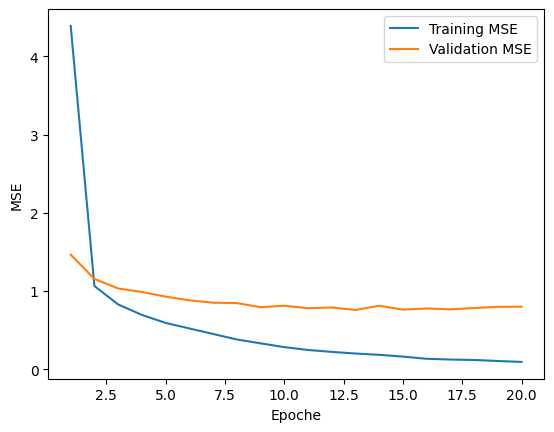

In [16]:
# plot the training and validation losses
epochs = list(range(1, len(val_losses) + 1))

stats = pd.DataFrame({"epoch": epochs, "train_loss": train_losses, "val_loss": val_losses})

sns.lineplot(x=epochs, y=train_losses, label = "Training MSE")
sns.lineplot(x=epochs, y=val_losses, label = "Validation MSE")

plt.xlabel("Epoche")
plt.ylabel("MSE")
plt.legend()

plt.show()

## Testing

In [17]:
model.eval()
test_loss = 0.0
with torch.no_grad():
    for fingerprints, labels in test_dataloader:
        outputs = model(fingerprints)
        test_loss += criterion(outputs.squeeze(), labels).item()
test_loss /= len(test_dataloader)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.8761


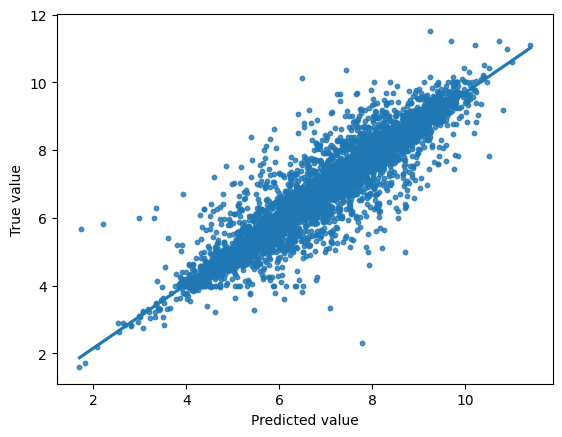

In [18]:
with torch.no_grad():
    sns.regplot(
        x=model(test_dataloader.dataset.dataset.fingerprints).squeeze().tolist(),
        y=test_dataloader.dataset.dataset.labels.tolist(),
        scatter_kws={"s": 10},
    )
plt.ylabel("True value")
plt.xlabel("Predicted value")
plt.show()

**Useful tutorials**:
* [Classes in Python](https://docs.python.org/3/tutorial/classes.html)
* [Tensors](https://docs.pytorch.org/tutorials/beginner/introyt/tensors_deeper_tutorial.html)
* [Dataloader & Dataset](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html)
* [Step by step Pytorch tutorial](https://docs.pytorch.org/tutorials/beginner/basics/intro.html)

## Exercises

### Exercise 1

In [19]:
# Create a MLP 'ActivityNetV2' that has 4 layers:
# input layer (1024 neurons)
# -> hidden layer with 256 neurons and ReLU activation
# -> hidden layer with  512 neurons and sigmoid activation
#    (https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html#torch.nn.Sigmoid)
# -> output layer (1 neuron)

class ActivityNetV2(nn.Module):
    def __init__(self):
        super(ActivityNetV2, self).__init__()
        self.fc1 = nn.Linear(1024, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        x = self.fc3(x)
        return x

In [20]:
# Train the model using the Adams optimizer and the MSE loss function in 20 epochs

model = ActivityNetV2()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses, val_losses = [], []
for epoch in range(num_epochs):
    train_loss = train_step(train_dataloader, model, criterion, optimizer)
    valid_loss = test_step(valid_dataloader, model, criterion)

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    print(
        f"Epoch: {epoch + 1:03d}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}"
    )

Epoch: 001, Train Loss: 3.5446, Validation Loss: 1.0762
Epoch: 002, Train Loss: 0.8774, Validation Loss: 0.9260
Epoch: 003, Train Loss: 0.6617, Validation Loss: 0.7785
Epoch: 004, Train Loss: 0.5233, Validation Loss: 0.7007
Epoch: 005, Train Loss: 0.3923, Validation Loss: 0.7019
Epoch: 006, Train Loss: 0.3096, Validation Loss: 0.6551
Epoch: 007, Train Loss: 0.2376, Validation Loss: 0.6875
Epoch: 008, Train Loss: 0.1910, Validation Loss: 0.6879
Epoch: 009, Train Loss: 0.1630, Validation Loss: 0.6554
Epoch: 010, Train Loss: 0.1300, Validation Loss: 0.6838
Epoch: 011, Train Loss: 0.1136, Validation Loss: 0.6879
Epoch: 012, Train Loss: 0.0944, Validation Loss: 0.6645
Epoch: 013, Train Loss: 0.0849, Validation Loss: 0.6842
Epoch: 014, Train Loss: 0.0803, Validation Loss: 0.6706
Epoch: 015, Train Loss: 0.0700, Validation Loss: 0.6803
Epoch: 016, Train Loss: 0.0683, Validation Loss: 0.6733
Epoch: 017, Train Loss: 0.0622, Validation Loss: 0.6734
Epoch: 018, Train Loss: 0.0583, Validation Loss:

In [21]:
# Test this model

model.eval()
test_loss = 0.0
with torch.no_grad():
    for fingerprints, labels in test_dataloader:
        outputs = model(fingerprints)
        test_loss += criterion(outputs.squeeze(), labels).item()
test_loss /= len(test_dataloader)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.7848


In [22]:
# Challenge: can you improve the runtime by changing the number of neurons in the hidden layers?

### Exercise 2 (Bonus) Graph neural network (GNN)
In this exercise you can implement a Graph Neural Network. Please look at the "Graph neural network (GNN)" of the [linked notebook](https://github.com/volkamerlab/ai_in_chemistry_workshop/blob/main/Session_1/Session_1.ipynb).

Try to transfer this to our activity prediction task.

In [23]:
# we need to first install some dependencies
!pip install torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html

Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 60.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.9 MB/s eta 0:00:00


In [24]:
# TODO